# CIBUSmod multi-processing example
This notebook privides an example of how to use multiple processes to run multiple scenarios/years faster.

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Instantiate a `Session` object and define scenarios in the same way as in the single-processing case. To make multi-processing work we need to instantiate the CIBUSmod modules and define the calculations in a separate file. Here we use `multi_proc.py` for this. This file defines a function `do_run()`  which performes the calculations. It is important that the `name` and `data_path` parameters to create `Session` object in `multi_proc.py` matches the `name` and `data_path` defined below in this notebook.

In [3]:
# Create session
session = cm.Session(
    name = 'fai_multi_proc', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'FAI',
    scenario = 'food_as_industry',
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)
session.add_scenario(
    name = 'FAI_no_cows',
    scenario = ['food_as_industry', 'no_cows'], 
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)

A scenario with the name 'FAI' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI_no_cows' already exists use .update_scenario() or .remove_scenario() instead.


### Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [5]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]

In [5]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=4) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

FAI, 2020 finished successfully in 8min 1s
FAI, 2025 finished successfully in 8min 33s
FAI, 2035 finished successfully in 8min 59s
FAI, 2030 finished successfully in 9min 21s
FAI, 2045 finished successfully in 6min 14s
FAI, 2040 finished successfully in 7min 2s
FAI, 2050 finished successfully in 7min 20s
FAI_no_cows, 2020 finished successfully in 7min 12s
FAI_no_cows, 2030 finished successfully in 6min 7s
FAI_no_cows, 2025 finished successfully in 6min 34s
FAI_no_cows, 2035 finished successfully in 6min 23s
FAI_no_cows, 2040 finished successfully in 6min 23s
FAI_no_cows, 2045 finished successfully in 4min 17s
FAI_no_cows, 2050 finished successfully in 4min 7s
CPU times: total: 62.5 ms
Wall time: 25min 47s


### Look at the data

Use `Session` to get a summary of scenarios and modules and their data attributes.

In [10]:
session

+------------------+
| CIBUSmod SESSION |
+------------------+
Name: multi_proc_test

SCENARIOS
FAI: [2020], [2025], [2030], [2035], [2040], [2045], [2050]
FAI_no_cows: [2020], [2025], [2030], [2035], [2040], [2045], [2050]

OUTPUT DATA
AnimalHerd
----------
ATTR                                 UNIT           ORIG                      DESC                                                             
bedding_material                     kg DM/year     ManureMgmt                Bedding material use                                             
bedding_material_K                   kg K/year      ManureMgmt                Bedding material use in terms of K                               
bedding_material_N                   kg N/year      ManureMgmt                Bedding material use in terms of N                               
bedding_material_P                   kg P/year      ManureMgmt                Bedding material use in terms of P                               
energy_use           

Use `Session.get_attr()` to retrieve specific data for all scenarios and years.

In [11]:
session.get_attr(
    module='c',
    attr='area',
    groupby='none'
)/1000

scn          year
FAI          2020    4268.570663
             2025    4481.930273
             2030    4600.188531
             2035    4711.457907
             2040    4822.265985
             2045    4935.229380
             2050    5040.153566
FAI_no_cows  2020    4268.570663
             2025    4349.054532
             2030    4310.535323
             2035    4240.731816
             2040    4148.890444
             2045    4024.777375
             2050    3819.605076
Name: value, dtype: float64

In [12]:
session.get_attr(
    module='A',
    attr='heads',
    groupby='species'
)/1000

species                cattle  horses         pigs       poultry       sheep
scn         year                                                            
FAI         2020  1431.160109   355.5  1408.839406  23621.161264  400.327851
            2025  1508.092663   355.5  1479.762765  24416.295478  406.281360
            2030  1567.925875   355.5  1535.564888  25031.044897  411.817821
            2035  1609.193689   355.5  1574.679274  25447.557093  419.321117
            2040  1635.983672   355.5  1600.909006  25733.342001  427.874155
            2045  1646.607801   355.5  1612.529752  25864.442536  436.515273
            2050  1636.094791   355.5  1604.838677  25772.614028  444.224859
FAI_no_cows 2020  1431.160109   355.5  1408.839406  23621.161264  400.327851
            2025  1330.669997   355.5  1479.761017  24416.295478  414.526346
            2030  1175.944394   355.5  1535.578295  25031.044897  424.829540
            2035   965.516214   355.5  1574.707302  25447.557093  435.093952
            2040   701.135859   355.5  1600.949492  25733.341878  450.846899
            2045   379.986416   355.5  1612.528832  25864.442536  469.157208
            2050     0.000003   355.5  1604.875292  25772.613825  477.443845

## Plot output
Here are some example output plots.

FAI
---


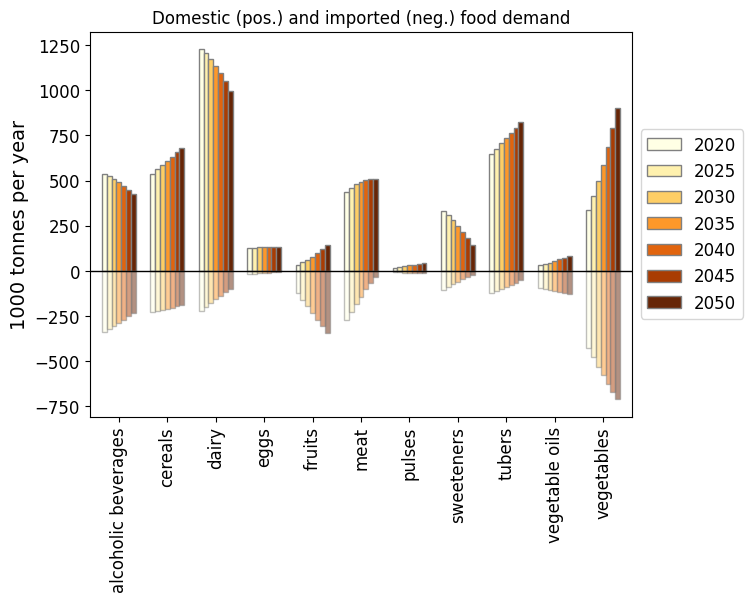

FAI_no_cows
-----------


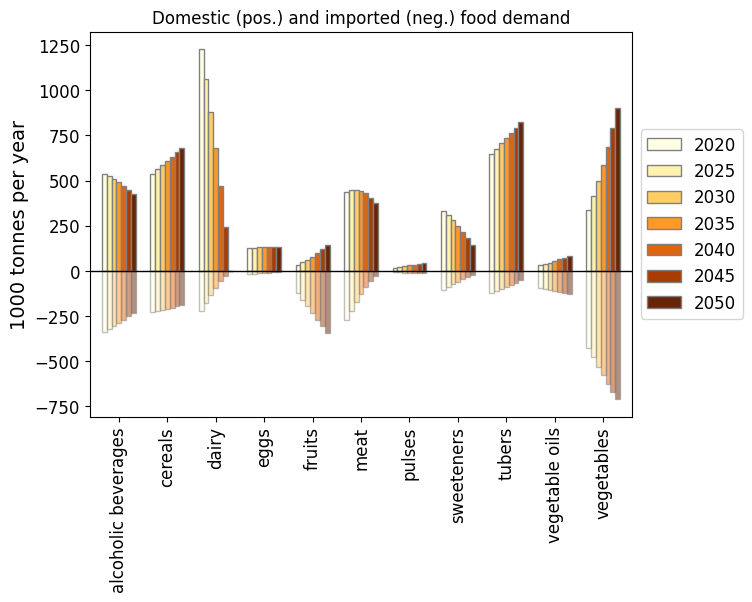

CPU times: total: 969 ms
Wall time: 1.13 s


In [6]:
%%time
style = {
    'kind' : 'bar',
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.7
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = (
        session.get_attr(
            module='D',
            attr='food_demand_to_processing',
            groupby=['origin','food_group']
        ).loc[scn]
        .stack()
    )/1000000
    plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']
    
    fig, ax = plt.subplots(figsize=(7,5))
    plot_data['domestic'].unstack('year').plot(**style, ax=ax)
    (
        plot_data['imported'].unstack('year')
        .rename({x:'_' for x in plot_data.index.get_level_values('year').unique()}, axis=1)
    ).plot(**style, ax=ax, alpha=0.5)
    
    plt.hlines(0,-1,11, color='black', linewidth=1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_ylabel('1000 tonnes per year', size=14)
    ax.set_title('Domestic (pos.) and imported (neg.) food demand', size=12)
    ax.set_xlabel('')
    ax.legend(loc='center left', ncol=1, bbox_to_anchor=(1, 0.5), fontsize=12)
    
    # plt.tight_layout()
    plt.show()

FAI
---


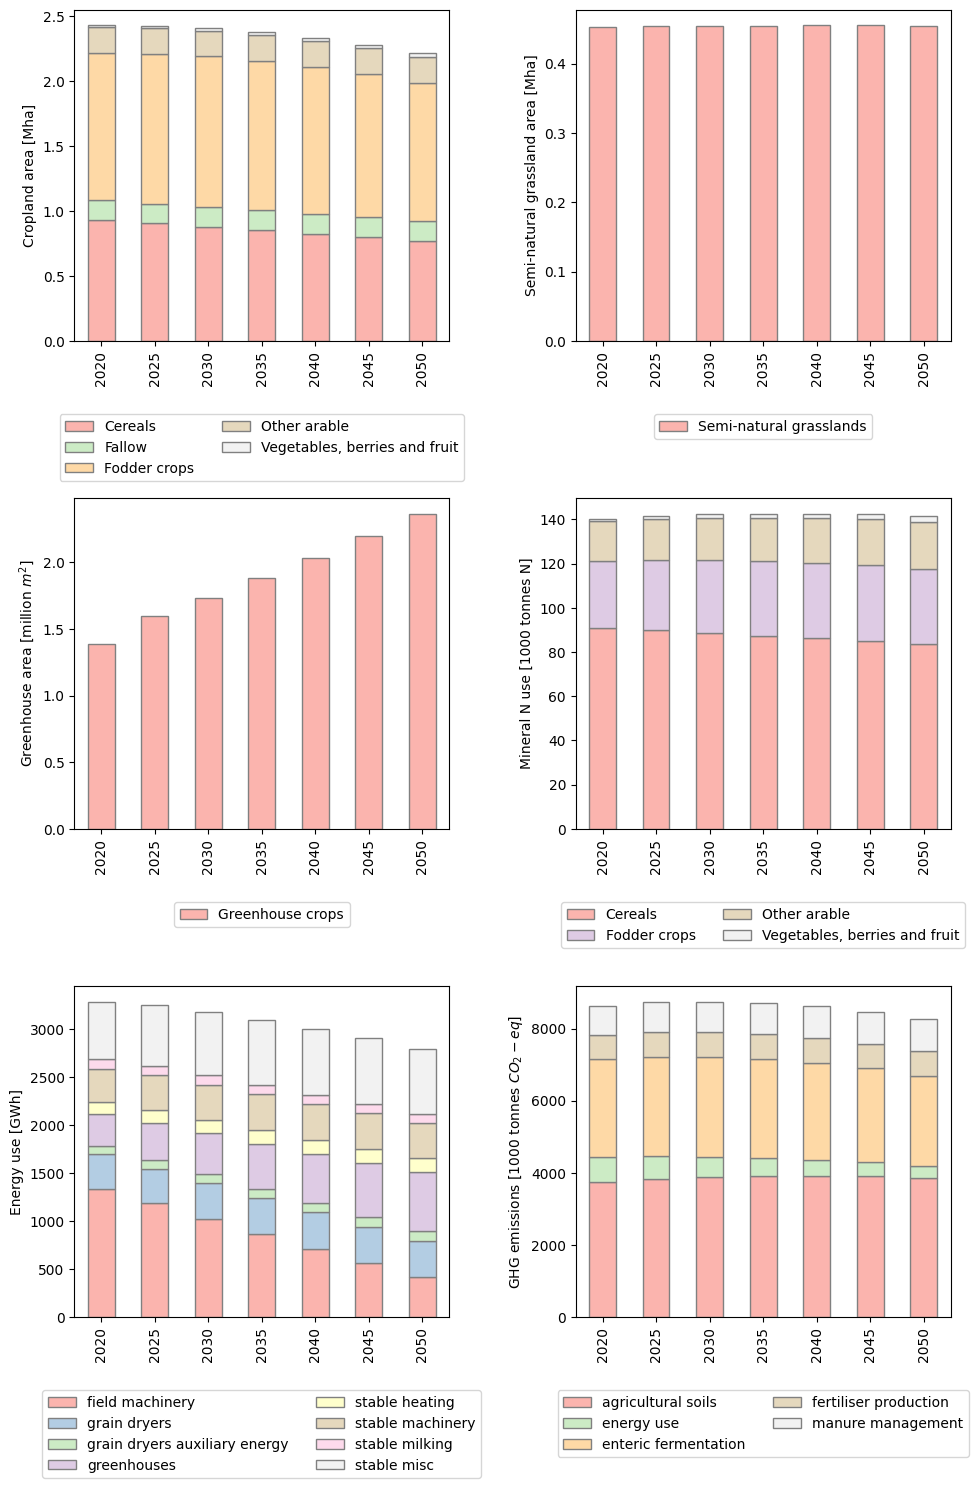

FAI_no_cows
-----------


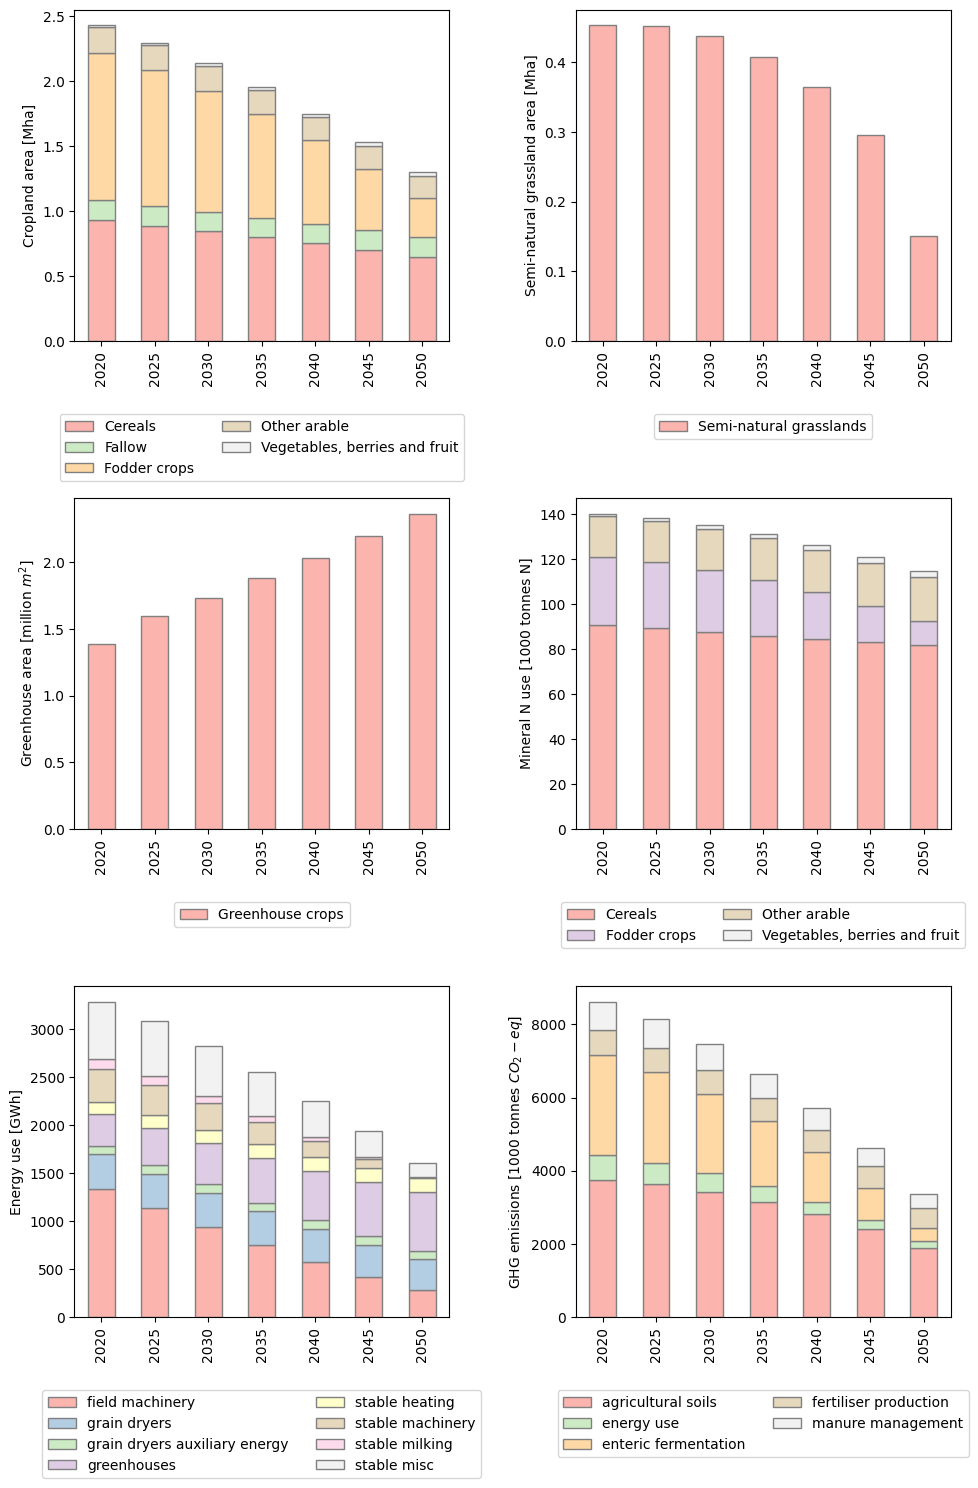

CPU times: total: 26.1 s
Wall time: 26.5 s


In [7]:
%%time
style = {
    'kind' : 'bar',
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.5
}

# Get data on GHG emissions
GHG_data = cm.get_GHG(session)

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))

    fig, axs = plt.subplots(3,2, figsize=(10,15))

    # Land use --->
    plot_data = session.get_attr('C','area',{'crop':'crop_group2'}).loc[scn]/1000000
    
    # Cropland
    ax = axs[0,0]
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Cropland area [Mha]')
    
    # Semi-natural grassland
    ax = axs[0,1]
    plot_data.xs('Semi-natural grasslands', axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Semi-natural grassland area [Mha]')
    
    # Greenhouse
    ax = axs[1,0]
    plot_data.xs('Greenhouse crops', axis=1).plot(**style, ax=ax)
    ax.set_ylabel(r'Greenhouse area [million $m^2$]')

    # Mineral N use --->
    ax = axs[1,1]
    (session.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000).loc[scn].plot(**style, ax=ax)
    ax.set_ylabel('Mineral N use [1000 tonnes N]')

    # Energy use --->
    ax = axs[2,0]
    pd.concat([
        session.get_attr('C','energy_use','activity').loc[scn]/1000000,
        session.get_attr('A','energy_use','activity').loc[scn]/1000000
    ], axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Energy use [GWh]')
    
    # GHG emissions
    ax = axs[2,1]
    plot_data = (GHG_data/1000000).loc[scn]
    (
        plot_data
        .T.groupby('process').sum().T
    ).plot(**style, ax=ax)
    ax.set_ylabel(r'GHG emissions [1000 tonnes $CO_{2}-eq$]')
    
    for ax in axs.flatten():
        ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=10)
        ax.set_xlabel('')

    fig.tight_layout()
    plt.show()

FAI
---


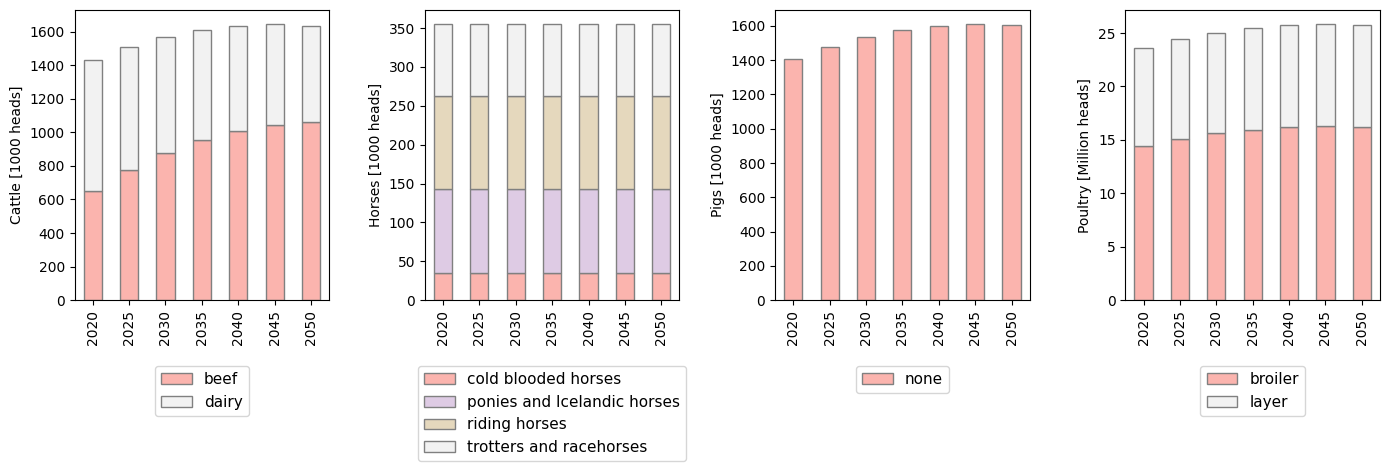

FAI_no_cows
-----------


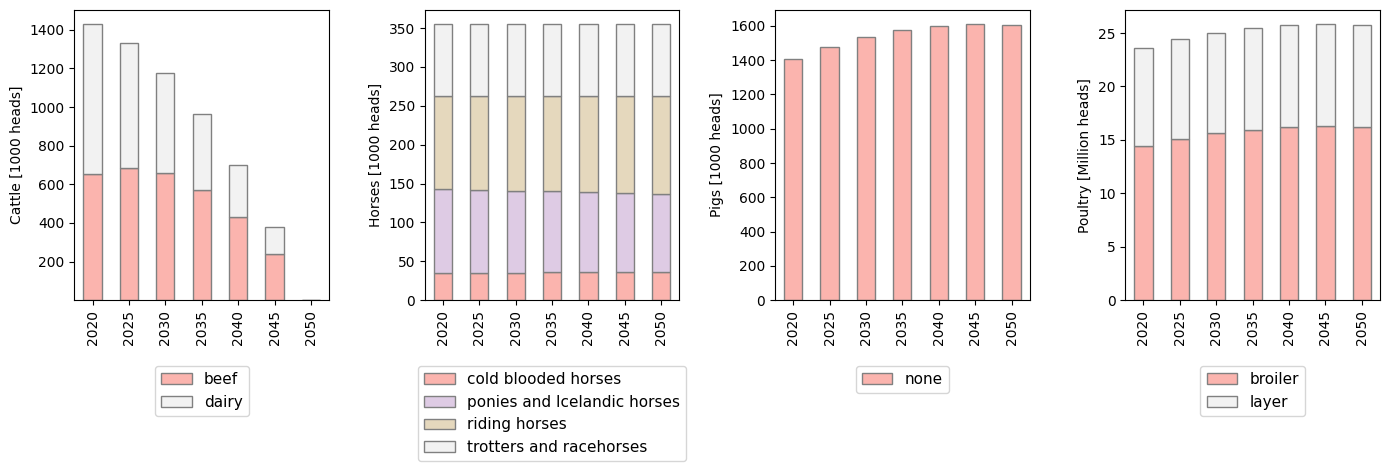

CPU times: total: 1.38 s
Wall time: 1.45 s


In [15]:
%%time
style = {
    'kind' : 'bar',
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.5
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    # Number of animal heads
    plot_data = session.get_attr('A','heads',['species','breed']).loc[scn]

    fig, axs = plt.subplots(1,4, figsize=(14,5))

    for ax,sp in zip(axs,plot_data.columns.get_level_values('species').unique()):

        (
            (plot_data / (1000000 if sp=='poultry' else 1000))
            .xs(sp, level='species', axis=1)
            .plot(**style, ax = ax)
        )

        ax.set_ylabel(sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]'))
        ax.set_xlabel('')
        ax.legend(loc='lower left', bbox_to_anchor=(0, 0))

    for ax in axs.flatten():
        ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.5, -0.2), fontsize=11)
        ax.set_xlabel('')
    
    plt.tight_layout()
    plt.show()

FAI
---


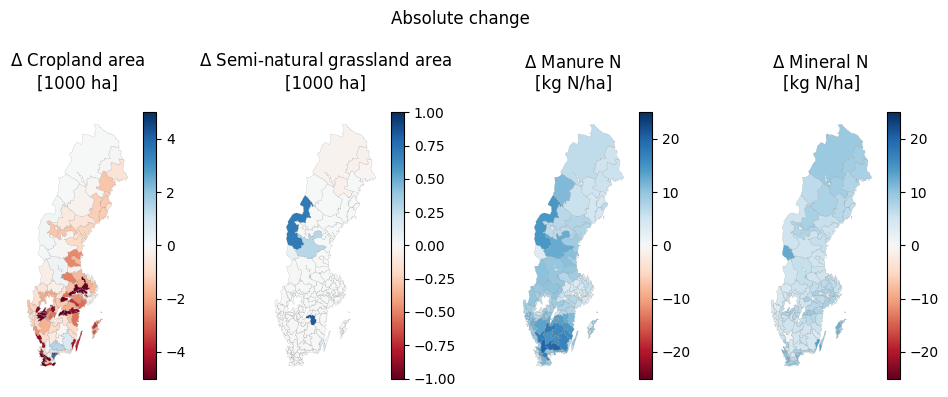

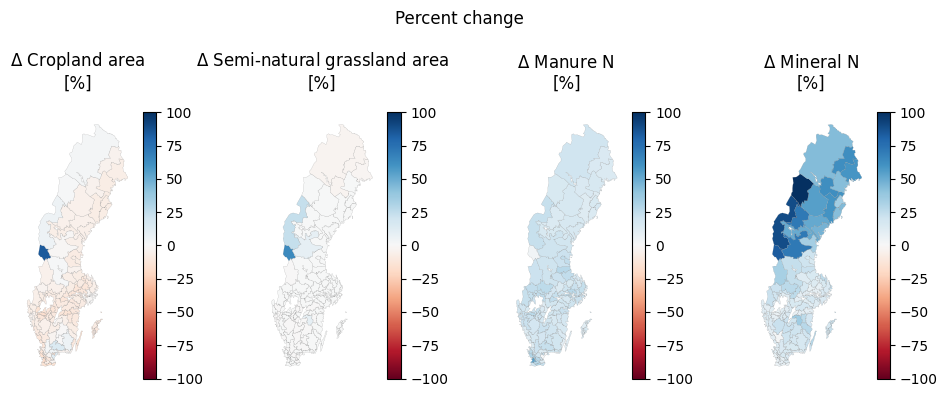

FAI_no_cows
-----------


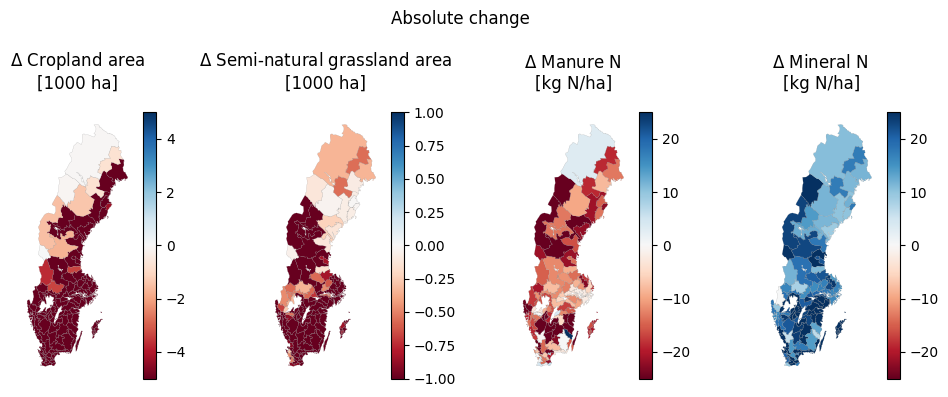

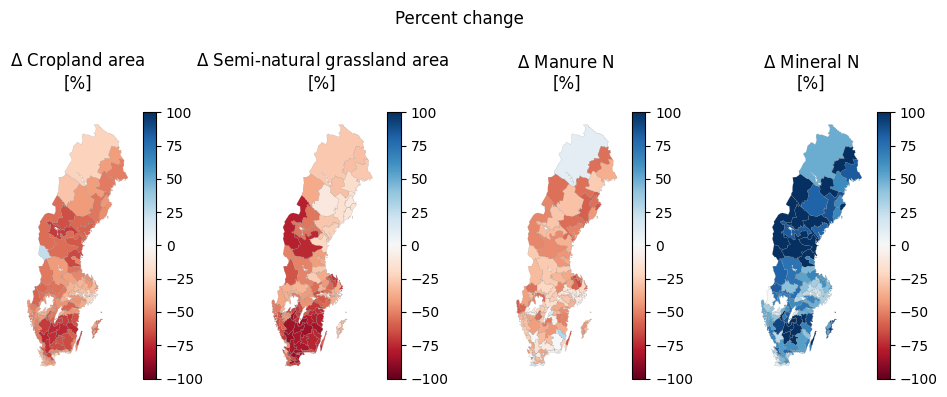

CPU times: total: 26.8 s
Wall time: 29.3 s


In [16]:
%%time
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    y0 = session.scenarios()[scn][0]
    yend = session.scenarios()[scn][-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-5,
        vmax=5,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-1,
        vmax=1,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle('Absolute change')
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[%]')
    ax.set_axis_off()
   
    
    plt.suptitle('Percent change')
    plt.tight_layout()
    plt.show()

FAI
---


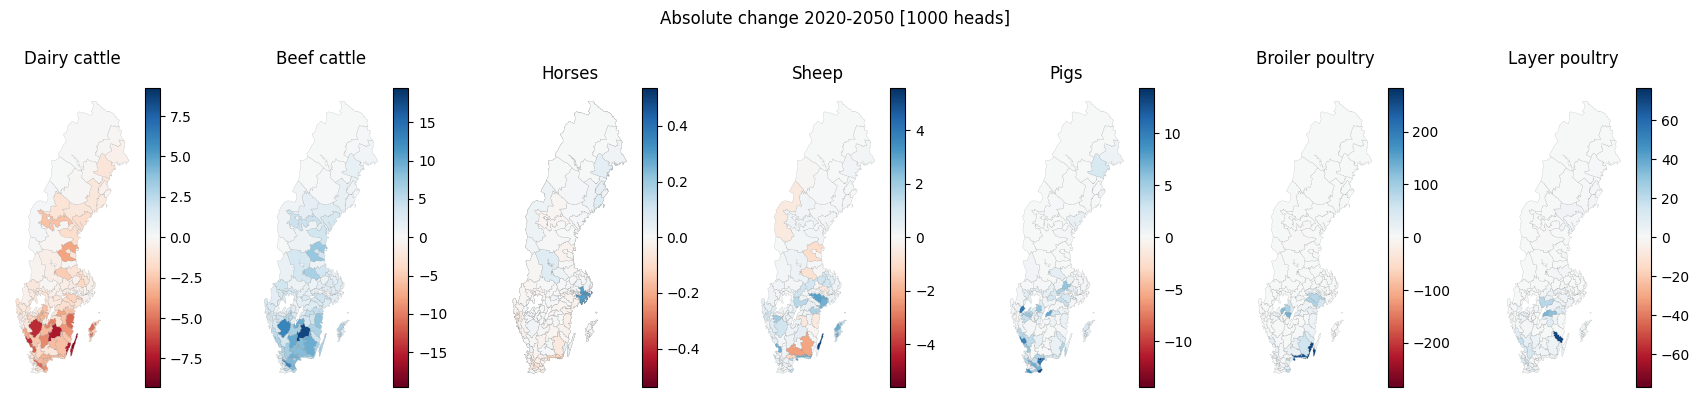

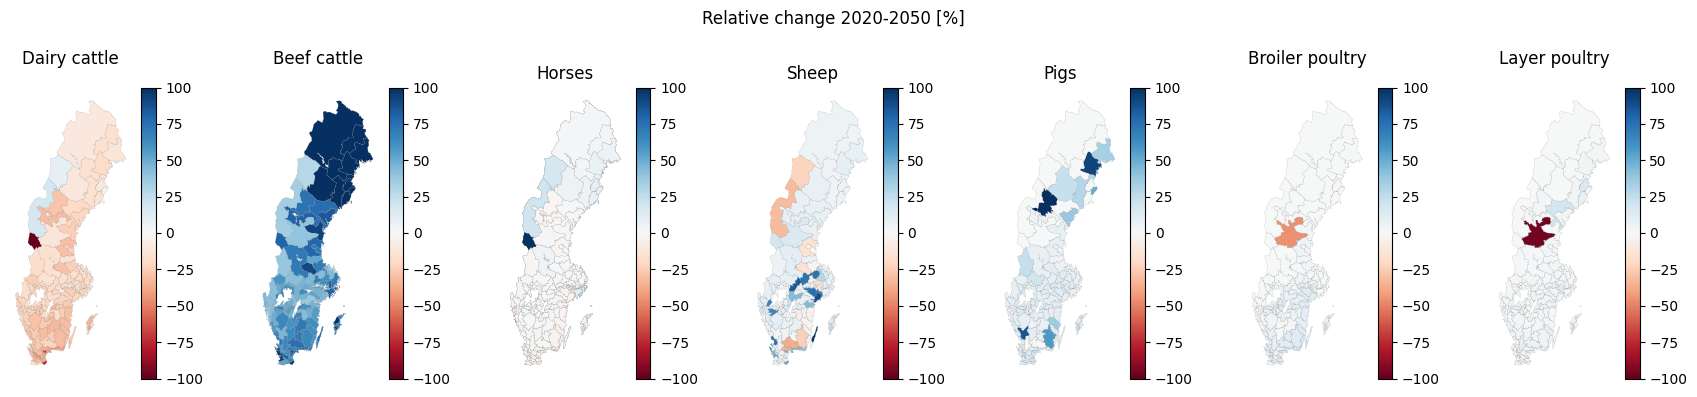

FAI_no_cows
-----------


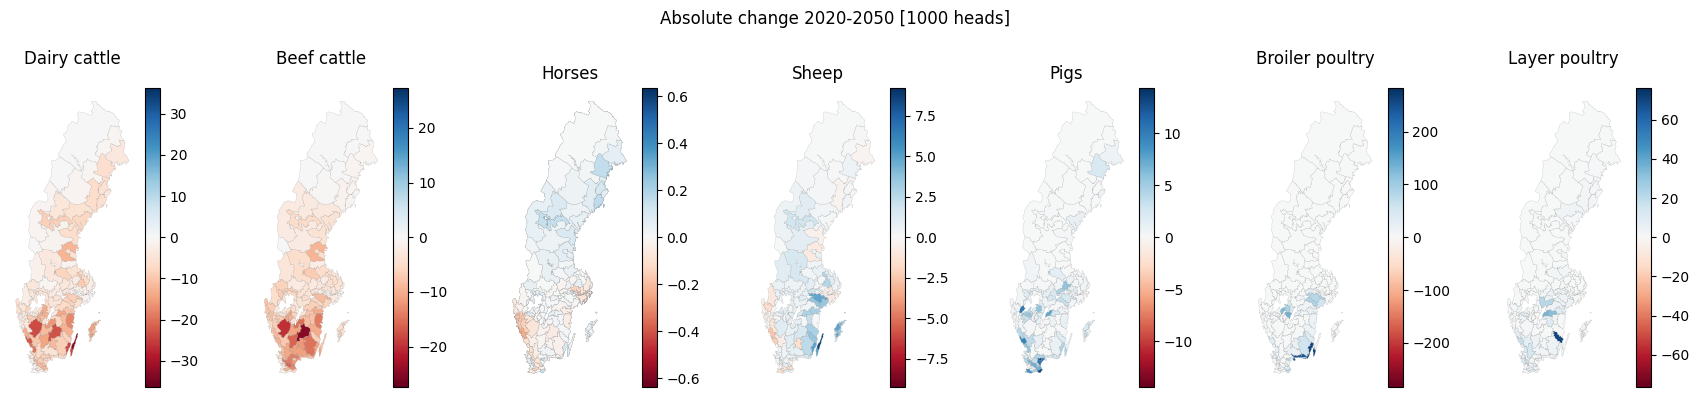

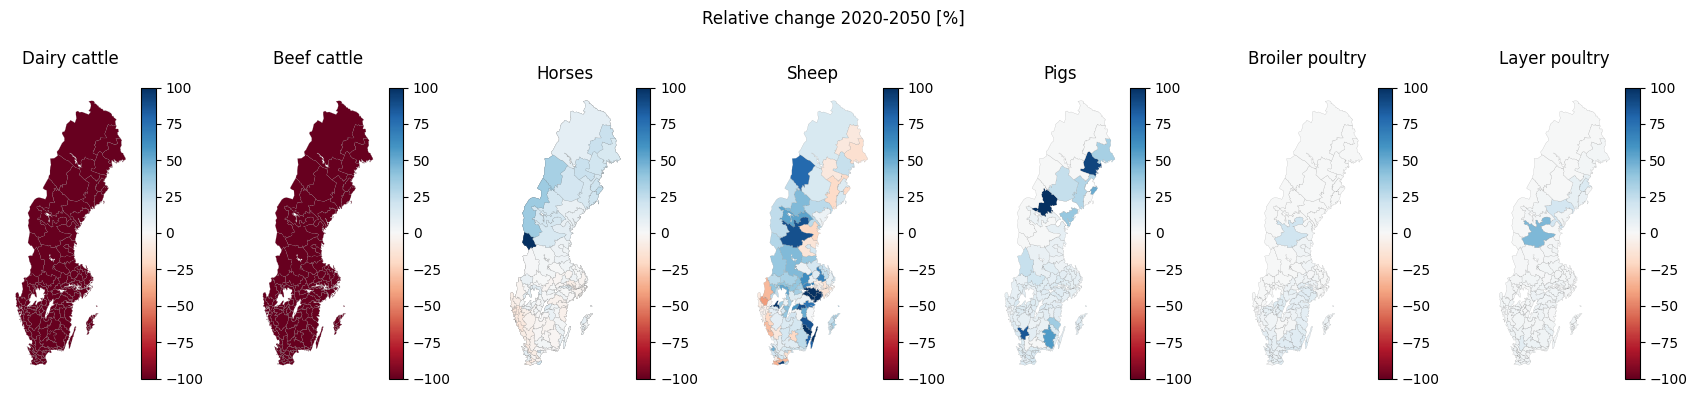

CPU times: total: 15.5 s
Wall time: 16.7 s


In [17]:
%%time
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Sheep':('sheep',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = session.get_attr('A','heads',['species','breed','region']).loc[scn]/1000
    plot_data_abs = (plot_data.loc['2050'] - plot_data.loc['2020']).sort_index()
    plot_data_prc = ((plot_data.loc['2050'] - plot_data.loc['2020']) / plot_data.loc['2020'] * 100).sort_index().fillna(0)
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle('Absolute change 2020-2050 [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle('Relative change 2020-2050 [%]')
    plt.tight_layout()
    plt.show()

### Output to ICBM
This is a work-in-progress interface to ICBM soil carbon modelling

In [18]:
%%time
from CIBUSmod.utils.output_data_manip_db import to_ICBM
icbm = to_ICBM(session)

CPU times: total: 36.3 s
Wall time: 37.4 s


FAI
---


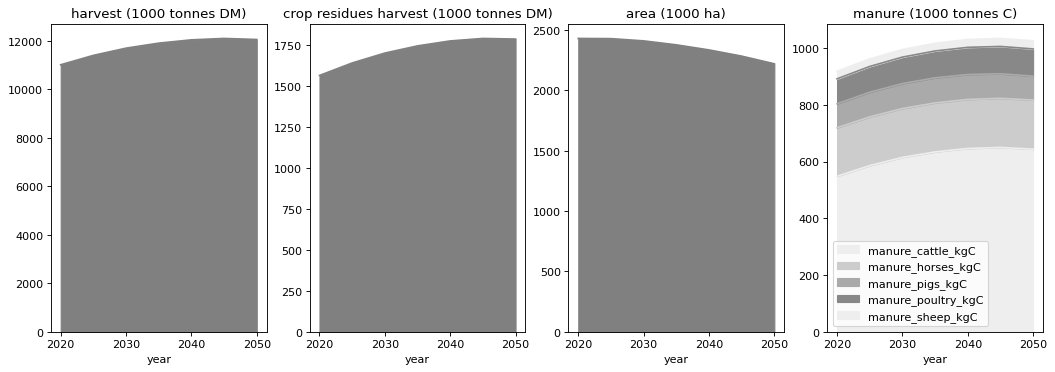

FAI_no_cows
-----------


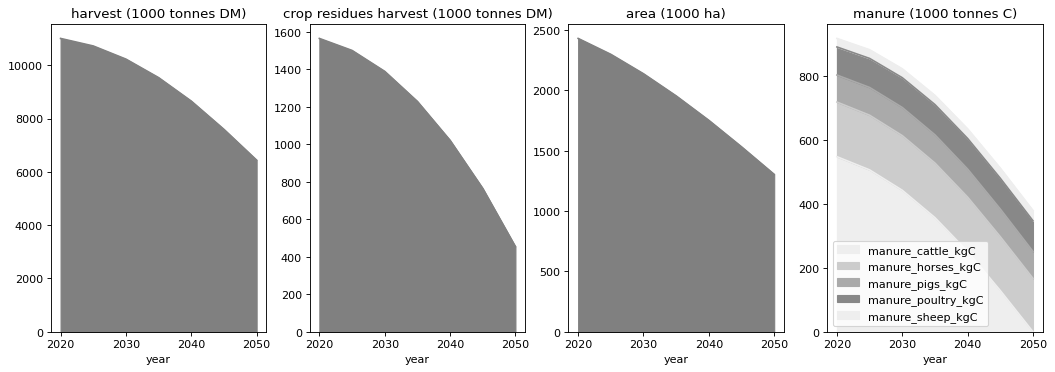

In [19]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))

    fig, axs = plt.subplots(1,4, figsize=(16,5), dpi=80)

    ax=axs[0]
    (icbm.loc[scn].groupby(['year']).sum()['harvest_kgdm']/1000000).plot(kind='area', color='grey', ax=ax)
    start, end = ax.get_xlim()
    ax.set_title('harvest (1000 tonnes DM)')
    
    ax=axs[1]
    (icbm.loc[scn].groupby(['year']).sum()['crop_residues_harvest_kgdm']/1000000).plot(kind='area', color='grey', ax=ax)
    start, end = ax.get_xlim()
    ax.set_title('crop residues harvest (1000 tonnes DM)')
    
    ax=axs[2]
    (icbm.loc[scn].groupby(['year']).sum()['area_ha']/1000).plot(kind='area', color='grey', ax=ax)
    start, end = ax.get_xlim()
    ax.set_title('area (1000 ha)')
    
    ax=axs[3]
    (icbm.loc[scn].groupby(['year']).sum().loc[:,'manure_cattle_kgC':]/1000000).plot(kind='area', color=['#eeeeee','#cccccc','#aaaaaa','#888888'], stacked=True, ax=ax)
    start, end = ax.get_xlim()
    ax.set_title('manure (1000 tonnes C)')
    plt.show()

In [16]:
# Write csv-files
from datetime import date
for scn in session.scenarios():
    icbm.loc[[scn]].to_csv(f'{scn}_to_ICBM_{date.today().strftime("%y%m%d")}.csv')